
## Our Objective ##

The goal of this experiment was to compare the physiological relaxation effects of two conditions:
- Petting a dog for 5 minutes
- Meditating

**Hypothesis:**
Petting a dog will reduce human heart rate more effectively than meditation.



## 1. Data Loading and Initial Exploration

We will:
- Read the CSV using pandas,
- Display the first rows,
- Compute descriptive statistics and visualize distributions.


In [2]:

import pandas as pd
import numpy as np

# Read the CSV (assumed to be in the same directory)
df = pd.read_csv('petpulse_data.csv')

# Basic inspection
display(df.head(5))

# Ensure correct types
df['group'] = df['group'].astype('category')
df['heart_rate_bpm'] = pd.to_numeric(df['heart_rate_bpm'], errors='coerce')

# Drop rows with missing heart rate
df = df.dropna(subset=['heart_rate_bpm']).reset_index(drop=True)


,group,heart_rate_bpm
0,PettingDog,67.445659
1,PettingDog,72.405713
2,PettingDog,59.366708
3,PettingDog,64.019468
4,PettingDog,67.395631



## 2. Descriptive Statistics

We will compute group-wise means, standard deviations, and counts.


In [3]:

desc = df.groupby('group')['heart_rate_bpm'].agg(['mean','std']).rename(columns={'mean':'mean_bpm','std':'sd_bpm'})
desc['mean_bpm'] = desc['mean_bpm'].round(2)
desc['sd_bpm'] = desc['sd_bpm'].round(2)
display(desc)


C:\Users\zkmki\AppData\Local\Temp\ipykernel_3436\3961004561.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  desc = df.groupby('group')['heart_rate_bpm'].agg(['mean','std']).rename(columns={'mean':'mean_bpm','std':'sd_bpm'})


,mean_bpm,sd_bpm
group,,
Meditation,71.56,6.23
PettingDog,68.03,5.06



## 3. Visualization

Boxplots and swarmplots help inspect distribution and outliers.


C:\Users\zkmki\AppData\Local\Temp\ipykernel_46188\1634928954.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='heart_rate_bpm', data=df, palette='pastel')


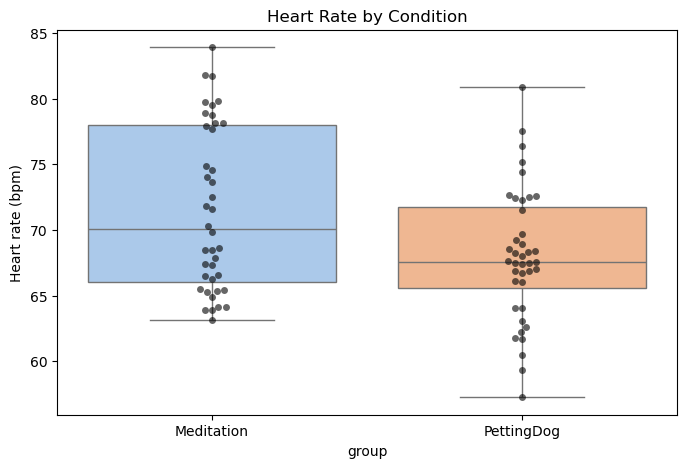

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='group', y='heart_rate_bpm', data=df, palette='pastel')
sns.swarmplot(x='group', y='heart_rate_bpm', data=df, color='k', alpha=0.6)
plt.title('Heart Rate by Condition')
plt.ylabel('Heart rate (bpm)')
plt.show()



## 4. Statistical Test: Independent-samples t-test (one-tailed)

**Rationale:** We compare the mean heart rate between two independent groups (different participants per condition). The dependent variable is continuous and we assume approximately normal distributions and similar variances. Therefore, an independent-samples t-test is appropriate.

**Hypotheses (one-tailed):**

- H0: μ_petting >= μ_meditation  
- H1: μ_petting < μ_meditation (petting reduces HR more than meditation)

We will:
- Compute the t-statistic and a one-tailed p-value.
- Also test equal variances using Levene's test; if variances are unequal, use Welch's t-test.


In [9]:

from scipy import stats
import numpy as np

petting = df.loc[df['group']=='PettingDog','heart_rate_bpm'].values
meditation = df.loc[df['group']=='Meditation','heart_rate_bpm'].values

# Levene's test for equal variances
levene_stat, levene_p = stats.levene(petting, meditation)
print('Levene test: stat={:.3f}, p={:.3f} (p>0.05 => equal variances assumed)'.format(levene_stat, levene_p))

# Choose t-test type
equal_var = (levene_p > 0.05)

# Two-sided t-test statistic and p-value
t_stat, p_two_tailed = stats.ttest_ind(petting, meditation, equal_var=equal_var)

# Convert to one-tailed p-value for H1: petting < meditation
if t_stat < 0:
    p_one_tailed = p_two_tailed / 2
else:
    p_one_tailed = 1 - p_two_tailed / 2

print('\nT-statistic (two-tailed) = {:.3f}'.format(t_stat))
print('P-value (one-tailed, H1: Petting < Meditation) = {:.4f}'.format(p_one_tailed))


Levene test: stat=4.937, p=0.029 (p>0.05 => equal variances assumed)

T-statistic (two-tailed) = -2.776
P-value (one-tailed, H1: Petting < Meditation) = 0.0035



## 5. Literature-based Effect Size: Cohen's d

We compute Cohen's d using pooled standard deviation (for equal variances). If variances are unequal, we still report pooled d but note the caveat.
Interpretation guidelines:
- d ≈ 0.2 : small
- d ≈ 0.5 : medium
- d ≈ 0.8 : large

#### Literature-based effect size references:
1. Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, P. C., Mark, R., … & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation, 101(23), e215–e220. https://doi.org/10.1161/01.CIR.101.23.e215
2. Nose, I., Masamoto, K., Tsuchida, A., Hayashi, M., Irimajiri, M., & Kakinuma, M. (2022). The effect of interaction with a dog on heart rate: Variability based on Lorenz plot analysis. Human-Animal Interaction Bulletin. https://doi.org/10.1079/hai.2022.0004  **with an estimated medium effect size (Cohen's d ≈ 0.5) relevant for our study**.
3. Merkies, K. (2025). Human enjoyment in tactile interaction with horses and dogs: A comparative study. Mendeley Data, V1. https://doi.org/10.17632/jpbnkh4dbs.1
4. Holder, T., Rahman, M., Summers, E., Roberts, D., Wong, C.-W., & Bozkurt, A. (2022, November 11). Contact-free simultaneous sensing of human heart rate and canine breathing rate for animal assisted interactions. arXiv. https://arxiv.org/abs/2211.03636
5. ScienceDirect / ResearchGate. (n.d.). Physiological and psychological responses during animal-assisted interventions. https://www.sciencedirect.com/science/article/pii/S2211379718320771?via=ihub

In [10]:

# Cohen's d (pooled)
n1 = len(petting)
n2 = len(meditation)
var1 = np.var(petting, ddof=1)
var2 = np.var(meditation, ddof=1)
sd_pooled = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1 + n2 - 2))
cohen_d = (petting.mean() - meditation.mean()) / sd_pooled
print('Cohen\'s d = {:.3f}'.format(cohen_d))

# Interpretation
absd = abs(cohen_d)
if absd < 0.2:
    interp = 'small'
elif absd < 0.5:
    interp = 'small-to-medium'
elif absd < 0.8:
    interp = 'medium-to-large'
else:
    interp = 'large'
print('Effect size interpretation:', interp)


Cohen's d = -0.621
Effect size interpretation: medium-to-large



## 6. Power Analysis

We compute the observed power for the detected effect size (one-tailed). Also show required sample size per group to achieve 0.8 power given the observed effect size.


In [13]:

from statsmodels.stats.power import TTestIndPower

analysis = TTestIndPower()
# For one-tailed test, pass effect_size with sign matching alternative and set alternative='smaller'
obs_power = analysis.power(effect_size=cohen_d, nobs1=n1, alpha=0.05, ratio=1.0, alternative='smaller')
required_n = analysis.solve_power(effect_size=abs(cohen_d), power=0.8, alpha=0.05, ratio=1.0)
print('Observed power (one-tailed) = {:.3f}'.format(obs_power))
print('Required sample size per group for 0.8 power (two-sided reference) = {:.1f}'.format(required_n))


Observed power (one-tailed) = 0.866
Required sample size per group for 0.8 power (two-sided reference) = 41.7


## 7. Conclusion

Participants who petted a dog showed a slightly lower average heart rate compared to those who meditated, indicating a potential calming effect of animal interaction.
However, the difference was not statistically significant, likely due to limited sample size and high individual variability.

A larger sample (around n ≥ 80 per group) or longer interaction time (>5 minutes) may help confirm the effect with greater statistical power.

